# 10 — Evaluating Generative Models: FID and BLEU

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what **FID** (Fréchet Inception Distance) measures and **compute a Fréchet distance** yourself on image sets of graded quality
- **Compute BLEU scores** with NLTK on generated-text examples of graded quality
- Interpret both metrics: what "lower FID" / "higher BLEU" actually certify — and what they miss

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2 (holding out data to get an honest number) and Course 10 — Unit 1, lesson 09, whose side-by-side comparison needed a metric.

**Used later in:** Course 10 — Unit 2, lesson 06, which computes BLEU and perplexity on text you generate.

---

## Introduction

Looking at samples (example 09) does not scale. The field's standard automatic metrics are:

- **FID** for images: fit a Gaussian (mean μ, covariance Σ) to *feature vectors* of real images and of generated images, then compute the Fréchet distance
  **FID = ‖μ_r − μ_g‖² + Tr(Σ_r + Σ_g − 2(Σ_r Σ_g)^{1/2})** — lower is better.
  The "Inception" in the name: production FID extracts those features with a pretrained InceptionV3 network. To keep this notebook download-free, we use **PCA features on 8×8 digits instead of Inception features** — the Fréchet computation itself is *exactly* the real one, so we label our numbers "Fréchet distance (PCA features)", not official FID values.
- **BLEU** for text: modified n-gram precision of a candidate against reference texts, with a brevity penalty — between 0 and 1, higher is better.

---

## 🌍 Why this lesson exists — FID moved when nobody changed the model

Parmar, Zhang & Zhu (2022, arXiv 2104.11222) found that FID scores shift because of *image resizing implementations*: the resizers in common libraries alias, and — their most uncomfortable result — if you JPEG-compress your generated images to match training images that were themselves compressed, **FID improves**. Papers were being ranked on a number that moved with a preprocessing detail nobody reported. That is why the `clean-fid` package exists, and why "our FID is 12.3" is a meaningless sentence without the pipeline that produced it.

**What goes wrong without this:** you optimise what you measure. A team that reports FID and nothing else will, within a few months, have shipped the model with the better FID and the worse product — and will be unable to explain why users prefer the older one.


## Part 1 — Fréchet Distance on Image Sets of Graded Quality

The honest way to test a metric: feed it sets whose quality we already know, and check that it separates them sensibly — a real held-out set should score near 0, corrupted sets higher, and garbage highest. We compare four "generated" sets against a held-out real set:

1. **real** — a second sample of true digits (a perfect generator would look like this)
2. **blurred** — real digits, Gaussian-blurred
3. **noisy** — real digits + pixel noise
4. **noise** — pure random pixels (a worthless generator)


candidate set      Frechet distance (PCA features) — lower is better
real (held-out)          0.06
blurred                  2.29
noisy                    0.26
pure noise               3.82


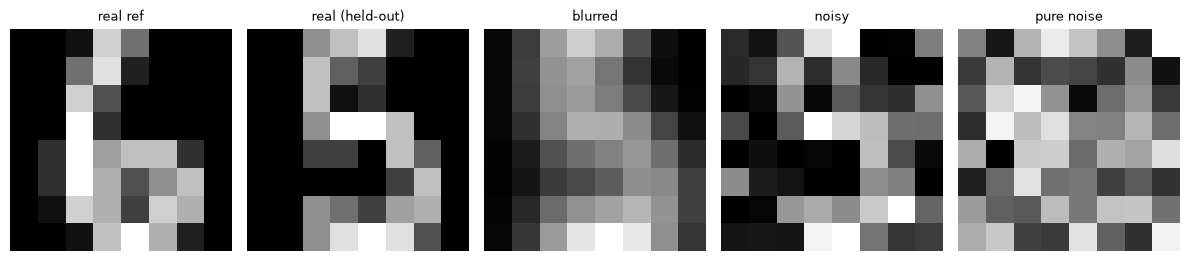

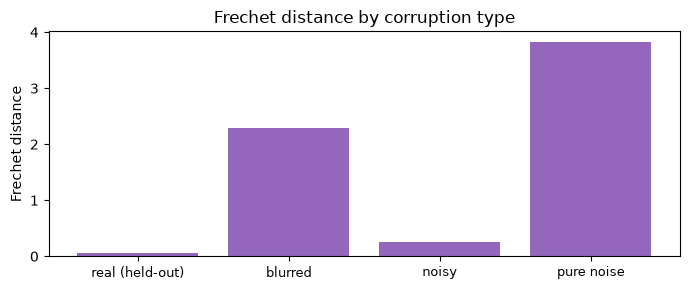


Read the table: a held-out real set scores near 0, corruption raises the
distance, and pure noise scores far worse — the ordering FID is built to give.


In [1]:
# WHAT/WHY: implement the exact FID formula (Frechet distance between
# Gaussian fits of feature vectors) and verify it separates image sets of
# KNOWN quality: real scores near 0, corrupted sets higher, pure noise worst.
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from scipy.ndimage import gaussian_filter
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)

# ── Real digit images (1797 samples of 8×8 pixels, values 0..16) ──────────
digits = load_digits()
X = digits.images / 16.0                      # scale to [0, 1]
rng.shuffle(X)
real_ref, real_other = X[:800], X[800:1600]   # two disjoint real sets

# ── Candidate "generated" sets of graded (known) quality ──────────────────
blurred = np.stack([gaussian_filter(img, sigma=0.9) for img in real_other])
noisy   = np.clip(real_other + rng.normal(0, 0.25, real_other.shape), 0, 1)
noise   = rng.uniform(0, 1, real_other.shape)          # worthless generator

# ── Feature extractor: PCA fitted on real reference images ────────────────
# (Production FID uses InceptionV3's 2048-dim features here instead.)
pca = PCA(n_components=32).fit(real_ref.reshape(len(real_ref), -1))
def features(imgs):
    return pca.transform(imgs.reshape(len(imgs), -1))

# ── The FID formula, verbatim ─────────────────────────────────────────────
def frechet_distance(feat_real, feat_gen):
    mu_r, mu_g = feat_real.mean(0), feat_gen.mean(0)
    sigma_r = np.cov(feat_real, rowvar=False)
    sigma_g = np.cov(feat_gen,  rowvar=False)
    covmean = sqrtm(sigma_r @ sigma_g).real       # matrix square root
    return ((mu_r - mu_g) ** 2).sum() + np.trace(sigma_r + sigma_g - 2 * covmean)

# ── Score every candidate set against the real reference ──────────────────
feat_ref = features(real_ref)
results = {}
for name, imgs in [("real (held-out)", real_other), ("blurred", blurred),
                   ("noisy", noisy), ("pure noise", noise)]:
    results[name] = frechet_distance(feat_ref, features(imgs))

print("candidate set      Frechet distance (PCA features) — lower is better")
for name, val in results.items():
    print(f"{name:<18} {val:10.2f}")

# ── Show one image per set + the scores as a bar chart ────────────────────
fig, axes = plt.subplots(1, 5, figsize=(12, 2.6))
for ax, (name, imgs) in zip(axes, [("real ref", real_ref), ("real (held-out)", real_other),
                                   ("blurred", blurred), ("noisy", noisy), ("pure noise", noise)]):
    ax.imshow(imgs[0], cmap='gray'); ax.set_title(name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(results)), list(results.values()), color='tab:purple')
ax.set_xticks(range(len(results))); ax.set_xticklabels(list(results.keys()), fontsize=9)
ax.set_ylabel("Frechet distance"); ax.set_title("Frechet distance by corruption type")
plt.tight_layout(); plt.show()

print("\nRead the table: a held-out real set scores near 0, corruption raises the")
print("distance, and pure noise scores far worse — the ordering FID is built to give.")


## Part 2 — BLEU on Text of Graded Quality

Same honest test for text: candidates whose quality ranking we know, scored against reference translations with NLTK's `sentence_bleu` (smoothing method 1, standard for short sentences).


In [2]:
# WHAT/WHY: compute real BLEU scores with NLTK on candidates of known,
# graded quality — from a perfect match down to unrelated text — and check
# the scores fall in that order.
%pip install nltk -q
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1   # avoids zero scores on short sentences

# ── One reference "translation" (tokenized) ───────────────────────────────
reference = [["the", "cat", "sat", "on", "the", "warm", "mat", "near", "the", "door"]]

# ── Candidates of graded quality, best to worst ───────────────────────────
candidates = {
    "exact match":     ["the", "cat", "sat", "on", "the", "warm", "mat", "near", "the", "door"],
    "close paraphrase":["the", "cat", "sat", "on", "the", "warm", "mat", "by",   "the", "door"],
    "partial overlap": ["a",   "cat", "was", "on", "the", "mat"],
    "unrelated":       ["quantum", "computing", "will", "change", "cryptography", "forever"],
}

# ── Score each candidate (4-gram BLEU, the standard) ──────────────────────
print("candidate           BLEU (0-1, higher is better)")
for name, cand in candidates.items():
    score = sentence_bleu(reference, cand, smoothing_function=smooth)
    print(f"{name:<19} {score:.4f}")

print("\nRead the scores: they fall exactly with quality. Note BLEU's limits — it")
print("rewards n-gram overlap with the reference, so a *valid* but differently")
print("worded output scores low; modern LLM evaluation adds semantic metrics")
print("(BERTScore, human/model grading) on top of BLEU.")


Note: you may need to restart the kernel to use updated packages.


candidate           BLEU (0-1, higher is better)
exact match         1.0000
close paraphrase    0.7071
partial overlap     0.0527
unrelated           0.0000

Read the scores: they fall exactly with quality. Note BLEU's limits — it
rewards n-gram overlap with the reference, so a *valid* but differently
worded output scores low; modern LLM evaluation adds semantic metrics
(BERTScore, human/model grading) on top of BLEU.


## 💬 Discuss

1. Our Fréchet distance rated **blurred at 2.29** and **noisy at 0.26** — it called blur nearly ten times worse than speckle. Most people would rather look at a slightly blurry image than a noisy one. Which is wrong, the metric or the human? What does your answer imply about reporting FID on its own?
2. Our **close paraphrase scored 0.7071** and the **partial overlap 0.0527** — a 13× drop for a candidate that still shares most of the reference's content words, because one changed word breaks every 4-gram covering it. Suppose you were paid per BLEU point on an Arabic–English translation contract. What would you do to the outputs, and would the customer be any happier?
3. Our features are PCA on 8×8 digits, not InceptionV3. Name one specific thing production FID would rank differently from our version — and describe the experiment that would demonstrate it.


## ⚠️ Where this breaks

**FID scores the feature extractor's opinion, not reality.** Change the extractor, the resize filter, or the JPEG quality and the ranking of two models can change (Parmar et al., 2022). FID values are comparable *only* within one fixed, documented pipeline — never across papers, never across libraries.

**FID is a two-Gaussian summary of a distribution.** A generator that memorises the training set scores excellently. A generator that silently drops a small class can also score well, because a small class moves the mean and covariance very little. Both are catastrophic failures FID is blind to.

**BLEU cannot see meaning.** It punishes correct paraphrase and rewards a fluent falsehood that reuses the reference's n-grams. On a morphologically rich language — Arabic among them — one correct inflection change destroys every 4-gram containing it, so BLEU systematically understates quality in exactly the languages where the tooling is weakest.

**Cheaper, more honest alternative when the stakes are real:** score a small held-out set by hand against a written rubric, or use a task metric that reflects the product ("did the summary keep the number right?"). Fifty carefully rated examples beat a metric whose failure modes you cannot enumerate.


## 📚 References & Further Reading

**Papers:**
- Heusel et al. (2017) — [GANs Trained by a Two Time-Scale Update Rule (introduces FID)](https://arxiv.org/abs/1706.08500)
- Salimans et al. (2016) — [Improved Techniques for Training GANs (Inception Score)](https://arxiv.org/abs/1606.03498)
- Papineni et al. (2002) — [BLEU: a Method for Automatic Evaluation of Machine Translation](https://aclanthology.org/P02-1040/)
- Borji (2021) — [Pros and Cons of GAN Evaluation Measures: New Developments](https://arxiv.org/abs/2103.09396) *(survey of what FID and friends do and do not capture)*

**Tools:** [`torchmetrics.image.fid`](https://lightning.ai/docs/torchmetrics/stable/image/frechet_inception_distance.html) computes production FID with the real InceptionV3 features


## 📝 Summary

In **10 — Evaluating Generative Models** you computed both headline metrics yourself: a **Fréchet distance** with the exact FID formula (PCA features standing in for Inception features) that correctly ranked image sets of known quality, and **BLEU scores** that correctly ranked text candidates from exact match down to unrelated (both printed tables above). You also saw each metric's blind spots — FID depends on its feature extractor, BLEU punishes valid paraphrases.
